# Import Libaries

In [17]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

# 0. Load data

In [3]:
path = kagglehub.dataset_download(
    "aslanahmedov/walmart-sales-forecast",
    output_dir="data"
)

DATA_DIR = Path(path)

FEATURES_DIR = DATA_DIR / "features.csv"
STORES_DIR = DATA_DIR / "stores.csv"
TEST_DIR = DATA_DIR / "test.csv"
TRAIN_DIR = DATA_DIR / "train.csv"

print("Path to features dataset files:", FEATURES_DIR)
print("Path to stores dataset files:", STORES_DIR)
print("Path to test dataset files:", TEST_DIR)
print("Path to train dataset files:", TRAIN_DIR)

Path to features dataset files: data\features.csv
Path to stores dataset files: data\stores.csv
Path to test dataset files: data\test.csv
Path to train dataset files: data\train.csv


# 1. Data inspection

In [4]:
features_df = pd.read_csv(FEATURES_DIR)
stores_df = pd.read_csv(STORES_DIR)
test_df = pd.read_csv(TEST_DIR)
train_df = pd.read_csv(TRAIN_DIR)

data_frames = {
    "features": features_df,
    "stores": stores_df,
    "test": test_df,
    "train": train_df
}

for name, df in data_frames.items():
    print("Data:", name.capitalize())
    print("Shape:", df.shape)
    print("Columns", list(df.columns))
    display(df.head(1))
    print()

Data: Features
Shape: (8190, 12)
Columns ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False



Data: Stores
Shape: (45, 3)
Columns ['Store', 'Type', 'Size']


,Store,Type,Size
0,1,A,151315



Data: Test
Shape: (115064, 4)
Columns ['Store', 'Dept', 'Date', 'IsHoliday']


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False



Data: Train
Shape: (421570, 5)
Columns ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.5,False


### Info
The dataset consists of four smaller datasets: `Features`, `Stores`, `Train`, and `Test`.
The `Features` dataset contains weekly information about each store, including **Temperature**, **Fuel Price**, **CPI**, **Unemployment**, **MarkDowns**, and holiday information.
The `Stores` dataset identifies each store and provides additional information such as its **Type** and **Size**.
The `Train` and `Test` datasets contain the main forecasting data, including **Store**, **Department**, **Date**, and **IsHoliday**. The `Train` dataset also contains the target variable, **Weekly_Sales**, which we will use to train the forecasting model.

# 2. Explorary data analysis

In [6]:
for name, df in data_frames.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


FEATURES
Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

STORES
Store    int64
Type       str
Size     int64
dtype: object

TEST
Store        int64
Dept         int64
Date           str
IsHoliday     bool
dtype: object

TRAIN
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object


### Info
Almost all features are stored as `int64` or `float64` data types. The exceptions are `Date` and `Type`, which are stored as strings (`str`), and `IsHoliday`, which contains boolean (`bool`) values.

In [15]:
for name, df in data_frames.items():
    print((df.isna().mean() * 100).sort_values(ascending=False))
    print()

MarkDown2       64.334554
MarkDown4       57.704518
MarkDown3       55.885226
MarkDown1       50.769231
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
Store            0.000000
Fuel_Price       0.000000
Temperature      0.000000
Date             0.000000
IsHoliday        0.000000
dtype: float64

Store    0.0
Type     0.0
Size     0.0
dtype: float64

Store        0.0
Dept         0.0
Date         0.0
IsHoliday    0.0
dtype: float64

Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64



### Info
There are a significant number of missing values in the `MarkDown` features, ranging from approximately **50% to 64%**. This will require further investigation before deciding how to handle these missing values.

In [13]:
for name, df in data_frames.items():
    if "Date" in df.columns:
        print(
            name,
            df["Date"].min(),
            df["Date"].max()
        )

features 2010-02-05 2013-07-26
test 2012-11-02 2013-07-26
train 2010-02-05 2012-10-26


### Info
The dates are correctly ordered and cover the period from the beginning of **2010 to the second half of 2012**.

In [20]:
train_df["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

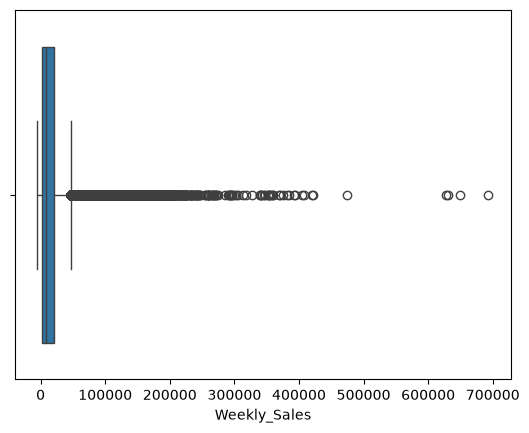

In [21]:
sns.boxplot(data=train_df, x="Weekly_Sales")
plt.show()

### Observation
The `Weekly_Sales` variable has a relatively high standard deviation compared to its mean, indicating substantial variation in sales across stores and departments. The values range from approximately **-5K to nearly 700K**, suggesting the presence of both negative sales and extreme high values.

The negative values may represent returns or sales adjustments, while the large positive values may be caused by differences between stores and departments.

In [42]:
train_df.groupby("Store")["Weekly_Sales"].mean().describe()

count       45.000000
mean     15438.091939
std       7011.232951
min       5053.415813
25%       9002.493073
50%      13803.596986
75%      19776.180881
max      29508.301592
Name: Weekly_Sales, dtype: float64

### Observation
The distribution of mean sales values and the boxplot above show that the extremely high sales values are outliers. These spikes appear to occur on specific dates, likely corresponding to periods with increased customer demand, such as major holidays or other peak shopping periods.

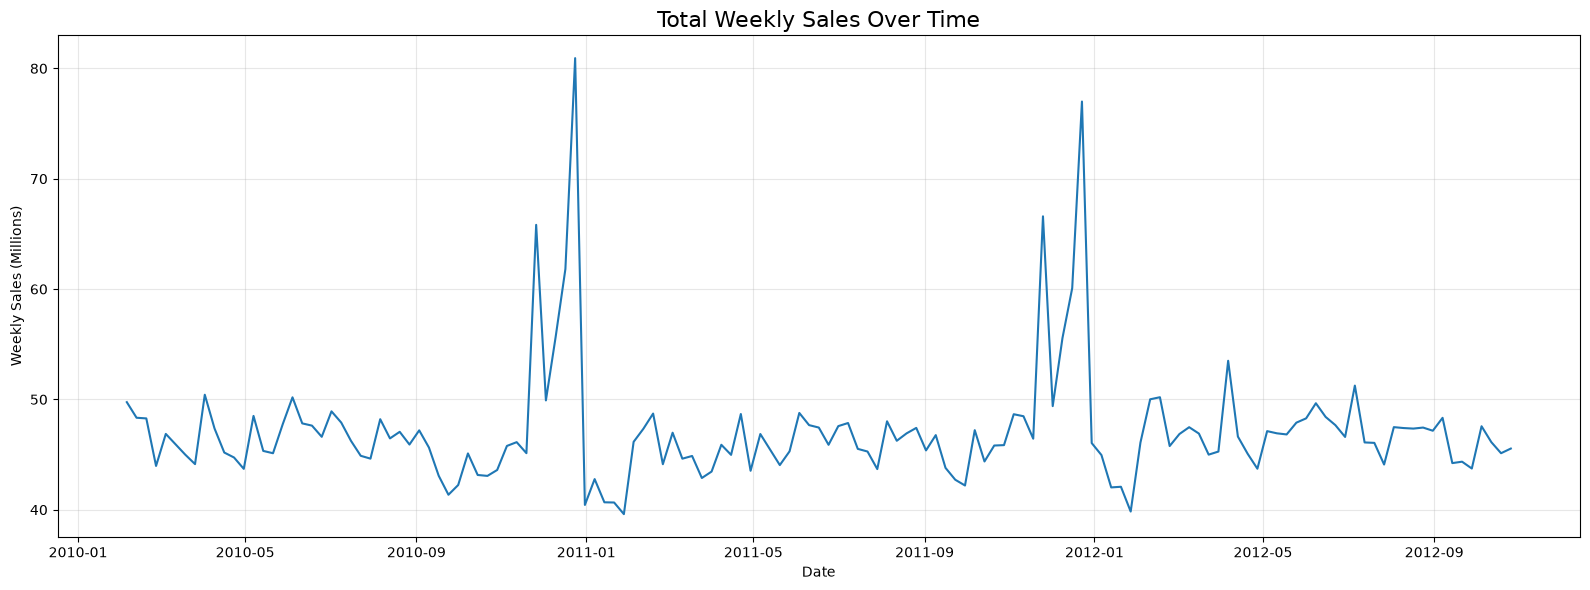

In [43]:
weekly_sales = (
    train_df
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

weekly_sales["Sales_Millions"] = weekly_sales["Weekly_Sales"] / 1_000_000

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=weekly_sales,
    x="Date",
    y="Sales_Millions",
    linewidth=1.5
)

plt.title("Total Weekly Sales Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Millions)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observation
The plot above clearly shows the trend in weekly sales over time. A significant spike in sales can be observed around the Christmas period, while during the rest of the year, weekly sales generally fluctuate within a range of approximately **±5 million** around the usual level.